## Data analysis of russian drone losses during the Ukrainian war (2022-2025) based on Oryx open-source dataset

In [1]:

def config(axis='y'):
    """
    Configuration of plot
    """
    ax = plt.gca()
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(axis=axis, alpha=0.2)
    ax.tick_params(axis='both', length=0)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('losses.csv')

drone = pd.DataFrame()
drone['date'] = data['date']
drone['drone'] = data['drone']

# Convert date to datetime type
drone['date'] = pd.to_datetime(drone['date'])
drone.info()    # verification

drone['year'] = drone['date'].dt.strftime('%Y')

drone_losses = pd.DataFrame()
drone_losses['nb_total'] = drone.groupby('year')['drone'].max()
drone_losses = drone_losses.reset_index()
drone_losses['yearly_loss'] = drone_losses['nb_total'] - drone_losses['nb_total'].shift(1)
drone_losses['yearly_loss'] = drone_losses['yearly_loss'].fillna(drone_losses['nb_total']).astype(int)
drone_losses = drone_losses.drop(index=drone_losses.index[-1])

# See the DataFrame
drone_losses


<class 'pandas.DataFrame'>
RangeIndex: 1445 entries, 0 to 1444
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1445 non-null   datetime64[us]
 1   drone   1445 non-null   int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 22.7 KB


,year,nb_total,yearly_loss
0,2022,1746,1746
1,2023,6591,4845
2,2024,21081,14490
3,2025,97684,76603


Text(0, 0, 'source : oryxspioenkop.com')

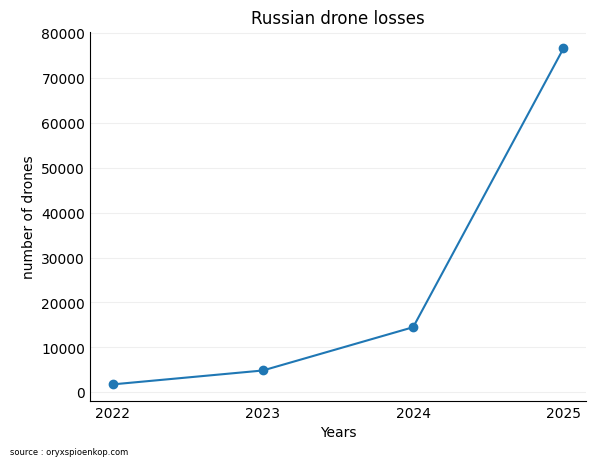

In [3]:
# Display the figure

plt.plot(drone_losses['year'], drone_losses['yearly_loss'])
plt.title('Russian drone losses')
plt.ylabel('number of drones')
plt.xlabel('Years')
config()
plt.scatter(drone_losses['year'], drone_losses['yearly_loss'])
plt.figtext(0, 0, 'source : oryxspioenkop.com', fontsize=6)

---

## 2026 inventory of russian aircrafts based on globalmilitary.net dataset

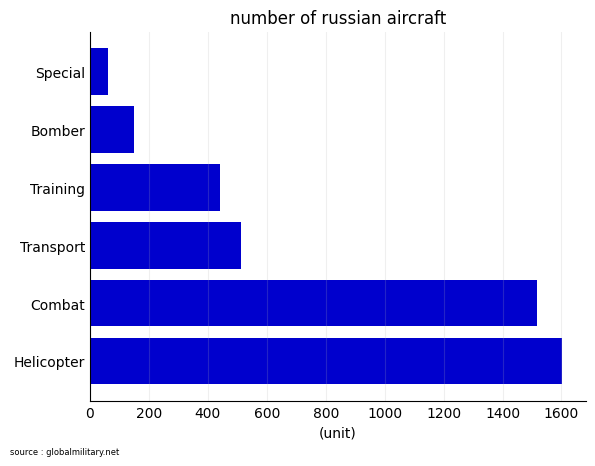

In [ ]:
def inventory(data, csv_file, dataframe, color, title):
    """
    horizontal plot for the country air force inventory
    """
    data = pd.read_csv(csv_file)
    dataframe = data.groupby('type')['active'].sum().reset_index()
    dataframe = dataframe.sort_values(by='active', ascending=False)

    #plot
    plt.barh(dataframe['type'], dataframe['active'], color=color)
    plt.title(title)
    plt.xlabel('(unit)')
    config('x')
    plt.figtext(0, 0, 'source : globalmilitary.net', fontsize=6)

inventory('data2', 'inventory.csv', 'inventory', 'mediumblue', 'number of russian aircraft')

In [5]:
# =========== Analytic Report =========== #
def report(filename, introduction):
    """
    Analytic report on inventory
    """
    data = pd.read_csv(filename)
    dataframe = data.groupby('type')['model_year'].mean().reset_index()
    dataframe['avg_age'] = 2026 - dataframe['model_year'].astype(int)

    # Most frequent model per category
    frequent_max = data.groupby('type')['active'].max().reset_index() # most active units 
    # create df merging type + most active units with model name
    frequent = frequent_max.merge(
        data[['type', 'active', 'model']],
        on=['type', 'active'],
        how='left'
)

    # Affect with the average category age
    dataframe['most_frequent_model'] = frequent['model']

    # Display
    print(introduction)
    for index, row in dataframe.iterrows():
        print(f'Type : {row["type"]}')
        print(f'Average age : {row["avg_age"]} years old')
        print(f'Most frequent model : {row["most_frequent_model"]}\n')

report('inventory.csv', '===================Analytic report on air force (RUSSIA)===================')


===================Analytic report on air force (RUSSIA)===================
Type : Bomber
Average age : 58 years old
Most frequent model : Tu-22M

Type : Combat
Average age : 37 years old
Most frequent model : Su-27/30/35

Type : Helicopter
Average age : 42 years old
Most frequent model : Mi-8/17/171

Type : Special
Average age : 47 years old
Most frequent model : Il-38

Type : Training
Average age : 39 years old
Most frequent model : L-39

Type : Transport
Average age : 47 years old
Most frequent model : Il-76



In [6]:
#test
#find the most active model
data = pd.read_csv('inventory.csv')
frequent_max = data.groupby('type')['active'].max().reset_index() # most active units 
# create df merging type + most active units with model name
frequent = frequent_max.merge(
    data[['type', 'active', 'model']],
    on=['type', 'active'],
    how='left'
)
frequent


,type,active,model
0,Bomber,57,Tu-22M
1,Combat,386,Su-27/30/35
2,Helicopter,777,Mi-8/17/171
3,Special,21,Il-38
4,Training,182,L-39
5,Transport,131,Il-76


In [7]:
data2 = pd.read_csv('inventory.csv')
data2['age'] = 2026 - data2['model_year']
bomber = data2.query('type == "Bomber"')
combat = data2.query('type == "Combat"')
helicopter = data2.query('type == "Helicopter"')
special = data2.query('type == "Special"')
training = data2.query('type == "Training"')
transport = data2.query('type == "Transport"')


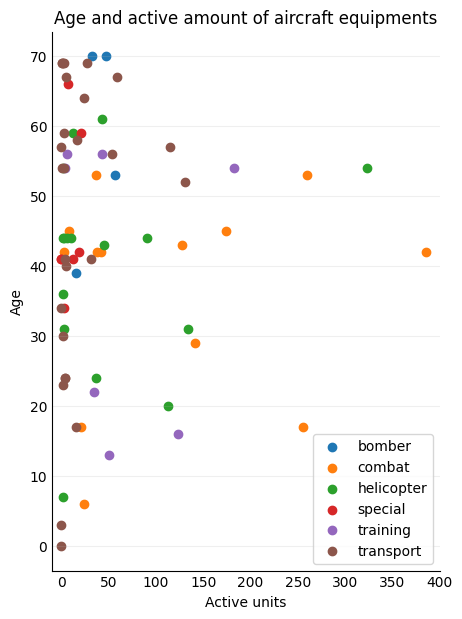

In [8]:
plt.figure(figsize=(5, 7))
plt.xlim(-10, 400)
plt.scatter(bomber['active'], bomber['age'], label='bomber')
plt.scatter(combat['active'], combat['age'],label='combat')
plt.scatter(helicopter['active'], helicopter['age'], label='helicopter')
plt.scatter(special['active'], special['age'],label='special')
plt.scatter(training['active'], training['age'],label='training')
plt.scatter(transport['active'], transport['age'],label='transport')
plt.title('Age and active amount of aircraft equipments')
plt.ylabel('Age')
plt.xlabel('Active units')
plt.legend()
config()

---
# Ukrainian air force inventory in 2026 (<i>ibid</i>)

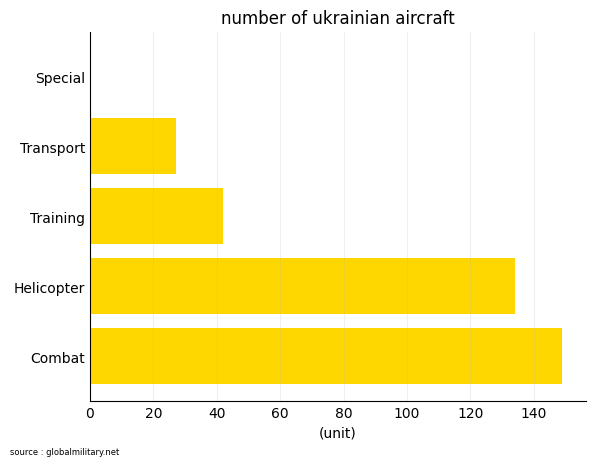

In [24]:
inventory('data3', 'inventoryukr.csv', 'inventoryukr', 'gold', 'number of ukrainian aircraft')

In [10]:
report('inventoryukr.csv', '===================Analytic report on air force (UKRAINE)===================')

===================Analytic report on air force (UKRAINE)===================
Type : Combat
Average age : 42 years old
Most frequent model : MiG-29

Type : Helicopter
Average age : 53 years old
Most frequent model : Mi-8

Type : Special
Average age : 29 years old
Most frequent model : Saab 340

Type : Training
Average age : 54 years old
Most frequent model : L-39

Type : Transport
Average age : 60 years old
Most frequent model : An-24/26



---
# Ukrainian/Russian inventories comparison (air forces)

Text(0.5, 1.0, 'UKRAINE')

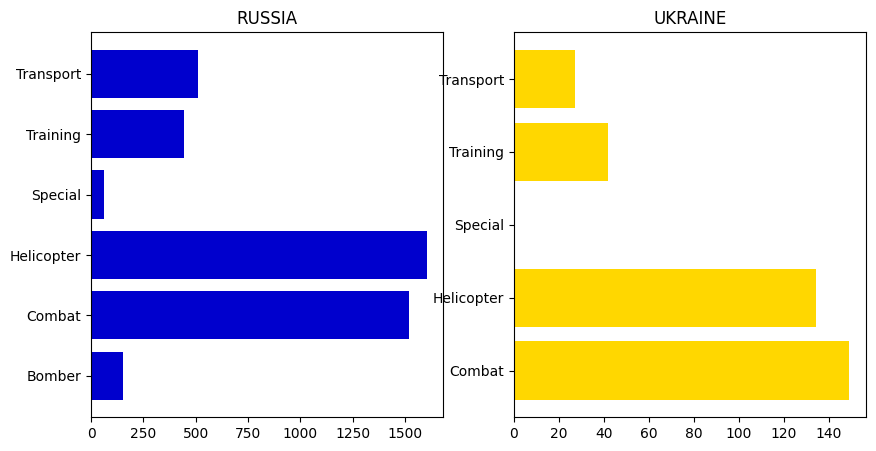

In [22]:
# get active units amounts per categories
data3 = pd.read_csv('inventoryukr.csv')
units_ru = data2.groupby('type')['active'].sum().reset_index()
units_ukr = data3.groupby('type')['active'].sum().reset_index()

# display multiple plots
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].barh(units_ru['type'], units_ru['active'], color='mediumblue')
axes[0].set_title('RUSSIA')
axes[1].barh(units_ukr['type'], units_ukr['active'], color='gold')
axes[1].set_title('UKRAINE')